In [1]:
import sys
sys.path.append('../../..')

from src import utils
import src.channelCoding as cc
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# MongoDB connection


client = MongoClient('mongodb://localhost:27017/')
# db = client['MAC_SC_R=1_2']
# TARGET_MAC = '3f8cd3da0bf84566839a7c790889884bab003e2de42c45d822188c14e1fbb719'
# MESSAGE = "This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of "


db = client['SIC_MAC_SC_R=0_5']
phase_SC_col = db['destination, phase_1']
phase_SC_col.find_one({}).keys()


db2 = client['MAC_1D_R=0_5']
phase_trad_col = db2['destination, phase_1']
phase_trad_col.find_one({}).keys()

/home/moh/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2025-07-21 18:39:31.529698: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-21 18:39:31.540649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753141171.552950 3588551 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for

dict_keys(['_id', 'Decoded_tag_success', 'Decoded_msg_success', 'BER_msg', 'BER_tag', 'message_hard_desicion', 'SNR', 'message', 'MAC', 'time', 'r0', 'r1', 'llr', 'decoded_phase_2', 'config'])

In [2]:
# Use list comprehensions and vectorized operations for faster processing
df_SC = pd.DataFrame(list(phase_SC_col.find({}, {'Decoded_tag_success':1, 'Decoded_msg_success':1, 'BER_msg': 1, 'BER_tag':1,'ber_t_after_rep':1, 'SNR': 1})))
df_SC.head()


from math import comb, ceil
def binomial_tail(n, p):
    k_start = ceil(n / 2)
    prob = 0
    for k in range(k_start, n + 1):
        prob += comb(n, k) * (p ** k) * ((1 - p) ** (n - k))
    return prob

df_SC['BER_tag'] = df_SC['BER_tag'].apply(lambda x:binomial_tail(19, x))


df_trad = pd.DataFrame(list(phase_trad_col.find({}, {'Decoded_tag_success':1, 'Decoded_msg_success':1, 'BER_msg': 1, 'BER_tag':1, 'SNR': 1})))
df_trad['SNR']= df_trad['SNR'].apply(lambda x: 10*np.log10(x))
df_trad.head()


# r0 = pd.DataFrame.from_dict(r0, orient='index')
# r1 = pd.DataFrame.from_dict(r1, orient='index')
# r_half = pd.DataFrame.from_dict(r_half, orient='index')


,_id,Decoded_tag_success,Decoded_msg_success,BER_msg,BER_tag,SNR
0,68740b4acb96ee6af731ebb9,True,True,0.0,0.0,17.368786
1,68740b4fcb96ee6af731ebbb,True,True,0.0,0.0,17.353483
2,68740b54cb96ee6af731ebbd,True,True,0.0,0.0,17.422521
3,68740b59cb96ee6af731ebbf,True,True,0.0,0.0,17.363001
4,68740b5fcb96ee6af731ebc1,True,True,0.0,0.0,17.332733


/tmp/ipykernel_3588551/3028464332.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SNR_bin').agg(
/tmp/ipykernel_3588551/3028464332.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SNR_bin').agg(


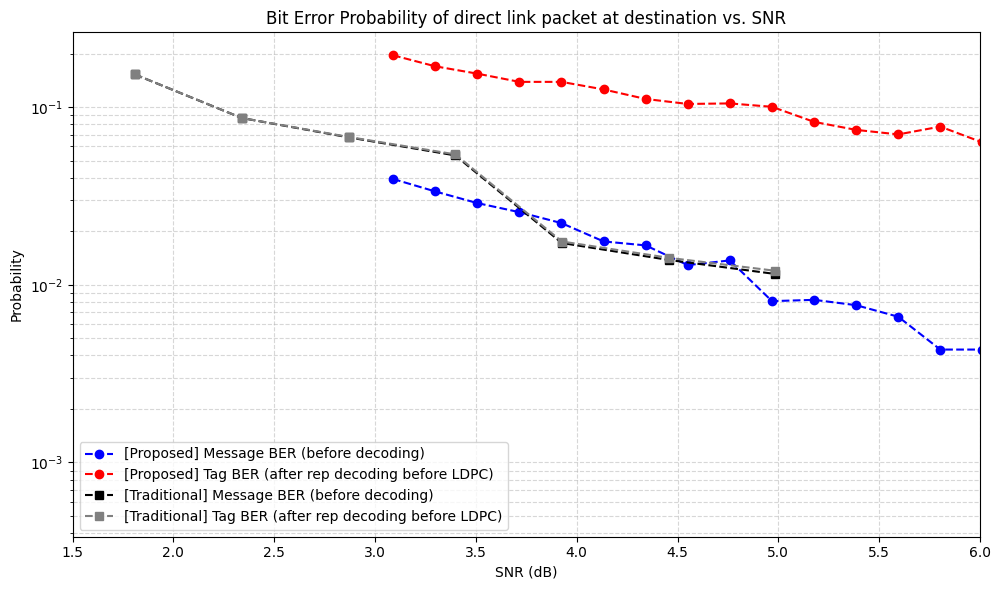

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def bin_and_aggregate(df, n_bins=10):
    # 1. Create equally spaced bins over SNR range
    snr_min = df['SNR'].min()
    snr_max = df['SNR'].max()
    bins = np.linspace(snr_min, snr_max, n_bins + 1)

    # 2. Bin the SNR values
    df['SNR_bin'] = pd.cut(df['SNR'], bins=bins, include_lowest=True)

    # 3. Aggregate per bin
    grouped = df.groupby('SNR_bin').agg(
        avg_BER_msg=('BER_msg', 'mean'),
        avg_BER_tag=('BER_tag', 'mean'),
        msg_fail_prob=('Decoded_msg_success', lambda x: (~x).mean()),
        tag_fail_prob=('Decoded_tag_success', lambda x: (~x).mean()),
        count=('BER_msg', 'count')
    ).reset_index()

    # 4. Also get bin centers for plotting
    grouped['bin_center'] = grouped['SNR_bin'].apply(lambda x: x.mid)

    return grouped


def plot_ber_and_error_prob(df_binned, title :str= "Proposed"):

    # Plot Message metrics (blue)
    plt.semilogy(df_binned['bin_center'], df_binned['avg_BER_msg'], 
             color='blue' if "P" in title.upper() else 'black', marker='o'if "P" in title.upper() else 's', linestyle='--', label=f'[{title}] Message BER (before decoding)')
    # plt.semilogy(df_binned['bin_center'], df_binned['msg_fail_prob'], 
    #          color='blue' if "P" in title.upper() else 'black', marker='o'if "P" in title.upper() else 's', linestyle='--', label=f'[{title}] Message decoding error probability')

    # plt.semilogy(df_binned['bin_center'], df_binned['msg_fail_prob'], 
    #          color='blue', marker='x', linestyle='-', label='Message Decode Error Probability')

    # Plot Tag metrics (red)
    plt.semilogy(df_binned['bin_center'], df_binned['avg_BER_tag'], 
             color='red' if "P" in title.upper() else 'grey', marker='o' if "P" in title.upper() else 's', linestyle='--', label=f'[{title}] Tag BER (after rep decoding before LDPC)')
    # plt.semilogy(df_binned['bin_center'], df_binned['tag_fail_prob'], 
    #          color='red' if "P" in title.upper() else 'grey', marker='o' if "P" in title.upper() else 's', linestyle='--', label=f'[{title}] Tag decoding error probability')

    # plt.semilogy(df_binned['bin_center'], df_binned['tag_fail_prob'], 
    #          color='red', marker='x', linestyle='-', label='Tag Decode Error Probability')

    # Style
    plt.xlabel('SNR (dB)')
    plt.ylabel('Probability')
    plt.title('Bit Error Probability of direct link packet at destination vs. SNR')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()


# -----------------
# Example usage:
# -----------------
# Load your DataFrame, e.g.:
# df = pd.read_csv('your_file.csv')



# Number of bins you want
n_bins = 30

# Compute binned results


binned_results = bin_and_aggregate(df_SC, n_bins=n_bins)
binned_results2 = bin_and_aggregate(df_trad, n_bins=n_bins)

# Plot nicely

plt.figure(figsize=(10, 6), dpi = 100)

plot_ber_and_error_prob(binned_results, title = "Proposed")
plot_ber_and_error_prob(binned_results2, title = "Traditional")

plt.xlim([1.5,6])

plt.show()



In [4]:
from scipy.special import erfc


# Define Q-function
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))
# Error rate function
def error_rate(l, R, p):

    # Avoid log(0) issues by adding a very small number when needed.
    p = np.where(p == 0, 1e-19, p)
    one_minus_p = 1 - p
    C = 1 + p * np.log2(p) + one_minus_p * np.log2(one_minus_p)
    denom = np.log2(one_minus_p / p)
    term = np.sqrt(l / (p * one_minus_p)) * ((C - R) / denom)
    return qfunc(term)





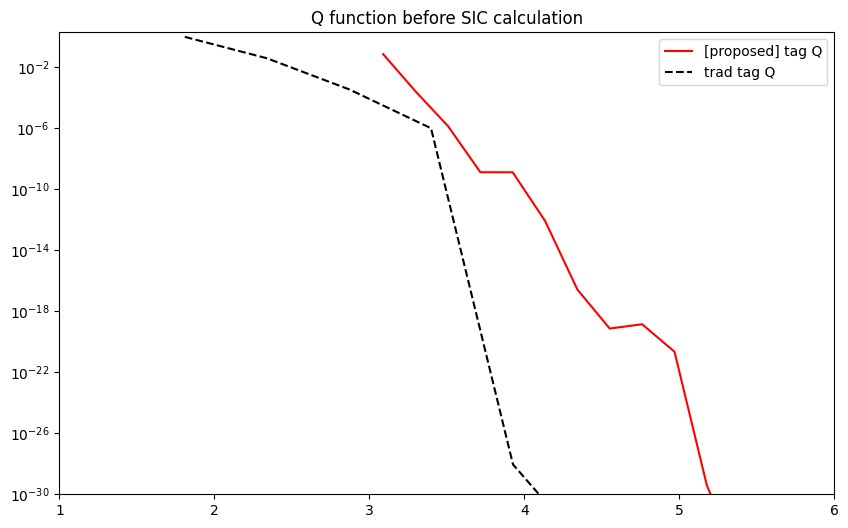

In [14]:
msg = binned_results['avg_BER_msg'].apply(lambda x:error_rate(19456, (19456-512)/2/19456, x))
tag = binned_results['avg_BER_tag'].apply(lambda x:error_rate(256*4, 1/4, x))


msg2 = binned_results2['avg_BER_msg'].apply(lambda x:error_rate(19456-512, .5, x))
tag2 = binned_results2['avg_BER_tag'].apply(lambda x:error_rate(512, .5, x))



plt.figure(figsize=(10, 6), dpi = 100)

# plot_ber_and_error_prob(binned_results, title = "Proposed")
# plot_ber_and_error_prob(binned_results2, title = "Traditional")

# plt.semilogy(binned_results['bin_center'],msg, label = "message Q" ,  color='red')
plt.semilogy(binned_results['bin_center'],tag, label = "[proposed] tag Q" , color='red')

# plt.semilogy(binned_results2['bin_center'],msg2, label = "trad message Q",  color='orange', linestyle='--')
plt.semilogy(binned_results2['bin_center'],tag2, label = "trad tag Q",  linestyle='--',color='black')

plt.title("Q function before SIC calculation")

plt.xlim([1,6])
plt.ylim([1e-30,2])
plt.legend()
plt.show()

In [6]:
256*19*4

19456